fs: 48000


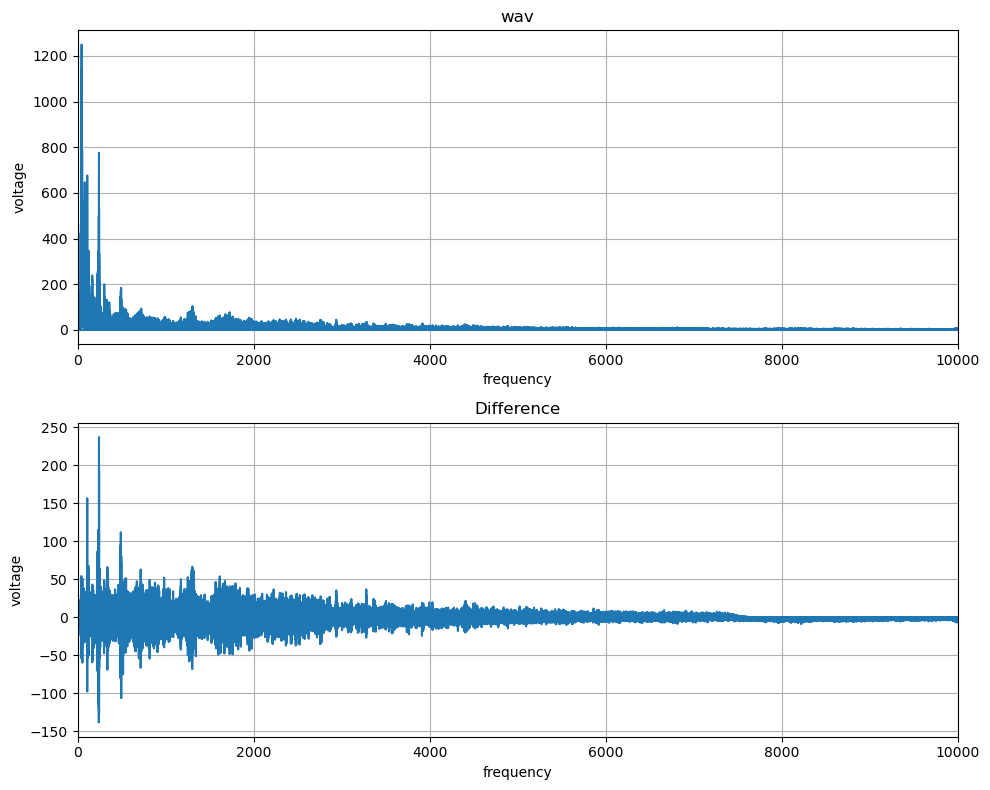

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
import scipy.signal as sp
from IPython.display import Audio
from pydub import AudioSegment

audio = AudioSegment.from_mp3("sample_music.mp3")
u1 = audio.get_array_of_samples()
fs1 = audio.frame_rate
print(f"fs: {fs1}")

fs0, u0 = wav.read("sample_music.wav")


# Plot Frequency Domain

def spectrum(u, fs):
    # Calculate Spectrum
    F = np.fft.fft(u)
    n = len(u)  # number of samples
    f = np.fft.fftfreq(n, 1/fs)  # frequency range
    volt = 2/n * np.abs(F)  # voltage of the DFT
    return f, volt

f1, volt1 = spectrum(u1, fs1)
f0, volt0 = spectrum(u0, fs0)

n = len(volt1)

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.title('wav')

plt.plot(f0[:n//2], volt0[:n//2])
plt.grid(True)    
plt.xlabel('frequency')
plt.ylabel('voltage')
plt.xlim(0, 10000)


plt.subplot(2, 1, 2)
plt.title('Difference')

plt.plot(f1[:n//2], volt1[:n//2]- volt0[:n//2])
plt.grid(True)    
plt.xlabel('frequency')
plt.ylabel('voltage')
plt.xlim(0, 10000)

plt.tight_layout()
plt.show()


audio = Audio(data=u0, rate=fs1)
display(audio)

